In [1]:
from pytrends.request import TrendReq
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pytrends = TrendReq(hl='en-US', tz=360)

Matplotlib is building the font cache; this may take a moment.


In [2]:
pytrends.build_payload(['Ozempic'], cat=0, timeframe='2020-01-01 2025-01-01', geo='', gprop='')
ozempic_trend = pytrends.interest_over_time()
ozempic_trend.head()

,Ozempic,isPartial
date,,
2019-12-29,2,False
2020-01-05,3,False
2020-01-12,3,False
2020-01-19,5,False
2020-01-26,3,False


In [3]:
nvo = yf.download('NVO', start='2020-01-01', end='2025-01-01')
nvo.head()

/var/folders/hm/sb7pzvvs70gg7xyty9xxqx7c0000gn/T/ipykernel_18884/3159769918.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvo = yf.download('NVO', start='2020-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVO,NVO,NVO,NVO,NVO
Date,,,,,
2020-01-02,26.509836,26.528006,26.350849,26.487124,2224800
2020-01-03,25.942030,26.073762,25.828468,25.851180,2491200
2020-01-06,25.896605,25.973827,25.833010,25.887521,2495000
2020-01-07,25.869349,25.892061,25.692193,25.892061,2080600
2020-01-08,25.823921,25.978365,25.742157,25.851177,1826200


In [4]:
df = ozempic_trend.join(nvo['Close'], how='inner')
df = df.rename(columns={'Ozempic': 'search', 'Close': 'price'})
df.head()

,search,isPartial,NVO


KeyError: 'price'

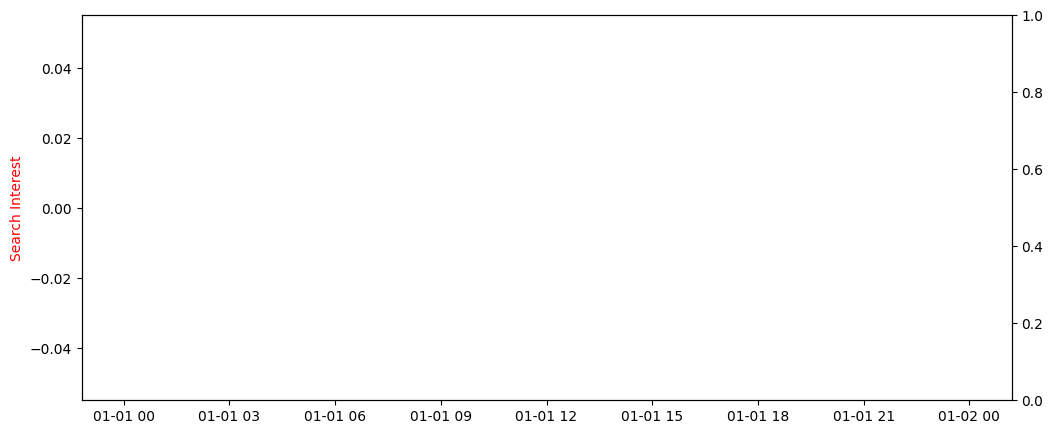

In [5]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(df.index, df['search'], color='red', label='Search Interest')
ax1.set_ylabel('Search Interest', color='red')

ax2 = ax1.twinx()
ax2.plot(df.index, df['price'], color='blue', label='Price')
ax2.set_ylabel('Price', color='blue')

plt.title('Ozempic Hype vs Novo Nordisk Price')
plt.show()

In [6]:
print(df.columns)

Index(['search', 'isPartial', 'NVO'], dtype='object')


In [7]:
df = df.rename(columns={'NVO': 'price'})

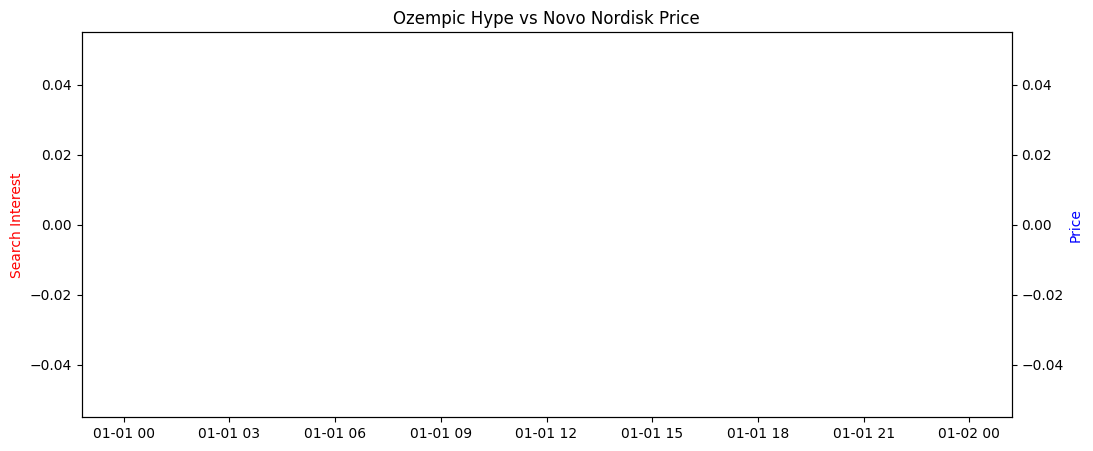

In [8]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(df.index, df['search'], color='red')
ax1.set_ylabel('Search Interest', color='red')

ax2 = ax1.twinx()
ax2.plot(df.index, df['price'], color='blue')
ax2.set_ylabel('Price', color='blue')

plt.title('Ozempic Hype vs Novo Nordisk Price')
plt.show()

In [9]:
df = df[['search', 'price']].dropna()

In [10]:
import numpy as np

lags = range(-30, 31)  # 30 days backward, 30 days forward
correlations = []

for lag in lags:
    shifted = df['search'].shift(lag)
    corr = shifted.corr(df['price'])
    correlations.append(corr)

In [11]:
corr_df = pd.DataFrame({'lag': lags, 'correlation': correlations})
corr_df.head()

,lag,correlation
0,-30,NaN
1,-29,NaN
2,-28,NaN
3,-27,NaN
4,-26,NaN


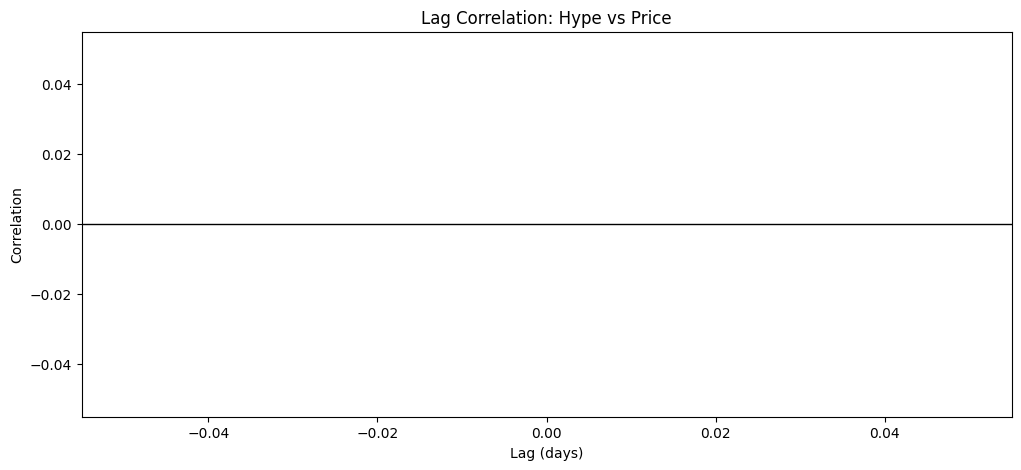

In [12]:
plt.figure(figsize=(12,5))
plt.plot(corr_df['lag'], corr_df['correlation'])
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Lag (days)')
plt.ylabel('Correlation')
plt.title('Lag Correlation: Hype vs Price')
plt.show()

In [13]:
print("DF shape:", df.shape)
print(df.head())
print(df.tail())
print(df[['search', 'price']].describe())

print("\nAny NaNs?")
print(df.isna().sum())

DF shape: (0, 2)
Empty DataFrame
Columns: [search, price]
Index: []
Empty DataFrame
Columns: [search, price]
Index: []
       search  price
count     0.0    0.0
mean      NaN    NaN
std       NaN    NaN
min       NaN    NaN
25%       NaN    NaN
50%       NaN    NaN
75%       NaN    NaN
max       NaN    NaN

Any NaNs?
search    0
price     0
dtype: int64


In [14]:
ozempic_trend.index

DatetimeIndex(['2019-12-29', '2020-01-05', '2020-01-12', '2020-01-19',
               '2020-01-26', '2020-02-02', '2020-02-09', '2020-02-16',
               '2020-02-23', '2020-03-01',
               ...
               '2024-10-27', '2024-11-03', '2024-11-10', '2024-11-17',
               '2024-11-24', '2024-12-01', '2024-12-08', '2024-12-15',
               '2024-12-22', '2024-12-29'],
              dtype='datetime64[ns]', name='date', length=262, freq=None)

In [15]:
nvo_weekly = nvo.resample('W-SUN').last()
nvo_weekly = nvo_weekly.rename(columns={'Close': 'price'})

In [16]:
df = ozempic_trend[['search']].join(nvo_weekly[['price']], how='inner').dropna()
print(df.shape)
df.head()

KeyError: "None of [Index(['search'], dtype='object')] are in the [columns]"

In [17]:
print(ozempic_trend.columns)
print(ozempic_trend.head())

Index(['Ozempic', 'isPartial'], dtype='object')
            Ozempic  isPartial
date                          
2019-12-29        2      False
2020-01-05        3      False
2020-01-12        3      False
2020-01-19        5      False
2020-01-26        3      False


In [18]:
# Inspect before renaming
print(ozempic_trend.columns)

Index(['Ozempic', 'isPartial'], dtype='object')


In [19]:
ozempic_trend = ozempic_trend.rename(columns={ACTUAL_COLUMN_NAME: 'search'})

NameError: name 'ACTUAL_COLUMN_NAME' is not defined

In [20]:
ozempic_trend = ozempic_trend.rename(columns={Ozempic: 'search'})

NameError: name 'Ozempic' is not defined

In [21]:
ozempic_trend = ozempic_trend.rename(columns={'Ozempic': 'search'})

In [22]:
if 'isPartial' in ozempic_trend.columns:
    ozempic_trend = ozempic_trend.drop(columns=['isPartial'])

In [23]:
print(ozempic_trend.head())
print(ozempic_trend.columns)

            search
date              
2019-12-29       2
2020-01-05       3
2020-01-12       3
2020-01-19       5
2020-01-26       3
Index(['search'], dtype='object')


In [24]:
from pytrends.request import TrendReq
import yfinance as yf
import pandas as pd

pytrends = TrendReq(hl='en-US', tz=360)

# 1. Get Google Trends
pytrends.build_payload(['Ozempic'], timeframe='2022-01-01 2025-01-01')
oz = pytrends.interest_over_time()

print("RAW TRENDS DF:")
print(oz.head())
print(oz.columns)

# 2. Find the keyword column (not isPartial)
cols = [c for c in oz.columns if c != 'isPartial']
keyword_col = cols[0]   # first non-isPartial column
print("Detected keyword column:", keyword_col)

# 3. Rename it
oz = oz.rename(columns={keyword_col: 'search'})

# 4. Drop isPartial if exists
if 'isPartial' in oz.columns:
    oz = oz.drop(columns=['isPartial'])

print("\nCLEANED TRENDS DF:")
print(oz.head())
print(oz.columns)

# 5. Get stock data
nvo = yf.download('NVO', start='2022-01-01', end='2025-01-01')[['Close']]
nvo = nvo.rename(columns={'Close': 'price'})

# 6. Weekly resample
nvo_weekly = nvo.resample('W-SUN').last()

# 7. Merge
df = oz.join(nvo_weekly, how='inner').dropna()

print("\nFINAL MERGED DF SHAPE:", df.shape)
print(df.head())

RAW TRENDS DF:
            Ozempic  isPartial
date                          
2021-12-26        8      False
2022-01-02       13      False
2022-01-09       14      False
2022-01-16       12      False
2022-01-23       11      False
Index(['Ozempic', 'isPartial'], dtype='object')
Detected keyword column: Ozempic

CLEANED TRENDS DF:
            search
date              
2021-12-26       8
2022-01-02      13
2022-01-09      14
2022-01-16      12
2022-01-23      11
Index(['search'], dtype='object')


/var/folders/hm/sb7pzvvs70gg7xyty9xxqx7c0000gn/T/ipykernel_18884/2452614075.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvo = yf.download('NVO', start='2022-01-01', end='2025-01-01')[['Close']]
[*********************100%***********************]  1 of 1 completed


MergeError: Not allowed to merge between different levels. (1 levels on the left, 2 on the right)

In [25]:
# 5. Get stock data (daily)
nvo = yf.download('NVO', start='2022-01-01', end='2025-01-01', group_by='column')
nvo = pd.DataFrame(nvo)  # make sure it's a normal DataFrame

print("\nRAW NVO COLUMNS:")
print(nvo.columns)

# If it's a MultiIndex, flatten it
if isinstance(nvo.columns, pd.MultiIndex):
    nvo.columns = [c[0] if isinstance(c, tuple) else c for c in nvo.columns]

print("\nFLATTENED NVO COLUMNS:")
print(nvo.columns)

# Keep just the close price and rename
if 'Close' in nvo.columns:
    nvo = nvo[['Close']].rename(columns={'Close': 'price'})
elif 'Adj Close' in nvo.columns:
    nvo = nvo[['Adj Close']].rename(columns={'Adj Close': 'price'})
else:
    print("Could not find Close / Adj Close in columns, got:", nvo.columns)

# 6. Weekly resample
nvo_weekly = nvo.resample('W-SUN').last()

print("\nNVO WEEKLY HEAD:")
print(nvo_weekly.head())

# 7. Merge
df = oz.join(nvo_weekly, how='inner').dropna()

print("\nFINAL MERGED DF SHAPE:", df.shape)
print(df.head())

/var/folders/hm/sb7pzvvs70gg7xyty9xxqx7c0000gn/T/ipykernel_18884/2985772607.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nvo = yf.download('NVO', start='2022-01-01', end='2025-01-01', group_by='column')
[*********************100%***********************]  1 of 1 completed


RAW NVO COLUMNS:
MultiIndex([( 'Close', 'NVO'),
            (  'High', 'NVO'),
            (   'Low', 'NVO'),
            (  'Open', 'NVO'),
            ('Volume', 'NVO')],
           names=['Price', 'Ticker'])

FLATTENED NVO COLUMNS:
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

NVO WEEKLY HEAD:
                price
Date                 
2022-01-09  48.047508
2022-01-16  45.599922
2022-01-23  45.145435
2022-01-30  45.808231
2022-02-06  47.185879

FINAL MERGED DF SHAPE: (156, 2)
            search      price
2022-01-09      14  48.047508
2022-01-16      12  45.599922
2022-01-23      11  45.145435
2022-01-30      12  45.808231
2022-02-06      17  47.185879


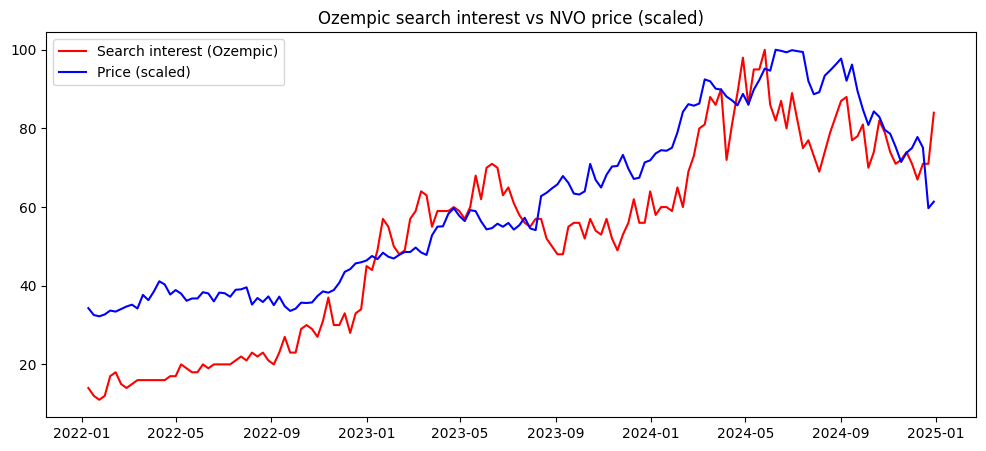

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.index, df['search'], label='Search interest (Ozempic)', color='red')

# scale price into similar range just for visual overlay
scaled_price = df['price'] / df['price'].max() * df['search'].max()
plt.plot(df.index, scaled_price, label='Price (scaled)', color='blue')

plt.legend()
plt.title('Ozempic search interest vs NVO price (scaled)')
plt.show()

In [27]:
import numpy as np
import pandas as pd

lags = range(-30, 31)  # from -30 to +30 weeks
correlations = []

for lag in lags:
    shifted = df['search'].shift(lag)
    temp = pd.concat(
        [shifted, df['price']],
        axis=1,
        keys=['search_shifted', 'price']
    ).dropna()
    
    if len(temp) > 10 and temp['search_shifted'].var() > 0 and temp['price'].var() > 0:
        corr = temp['search_shifted'].corr(temp['price'])
    else:
        corr = np.nan
    
    correlations.append(corr)

corr_df = pd.DataFrame({'lag': lags, 'correlation': correlations})

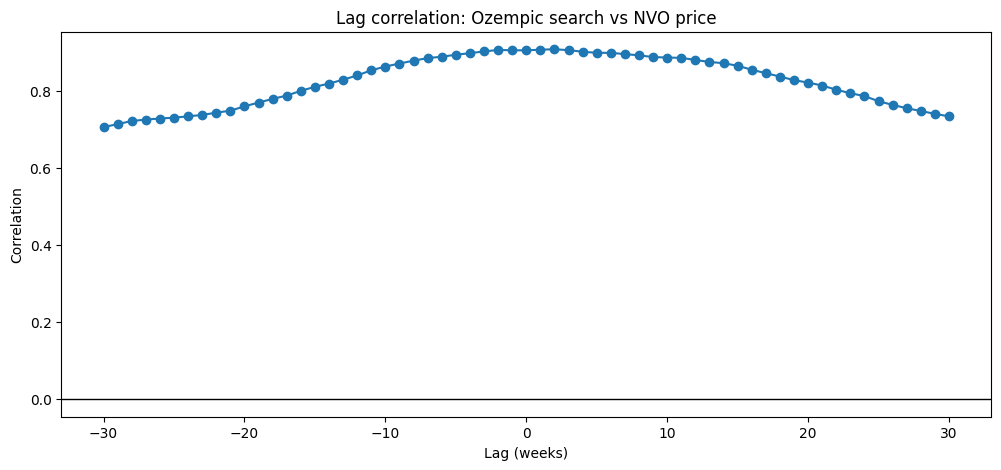

In [28]:
plt.figure(figsize=(12,5))
plt.plot(corr_df['lag'], corr_df['correlation'], marker='o')
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Lag (weeks)')
plt.ylabel('Correlation')
plt.title('Lag correlation: Ozempic search vs NVO price')
plt.show()

In [29]:
best_lag_row = corr_df.loc[corr_df['correlation'].idxmax()]
best_lag_row

lag            2.000000
correlation    0.909503
Name: 32, dtype: float64

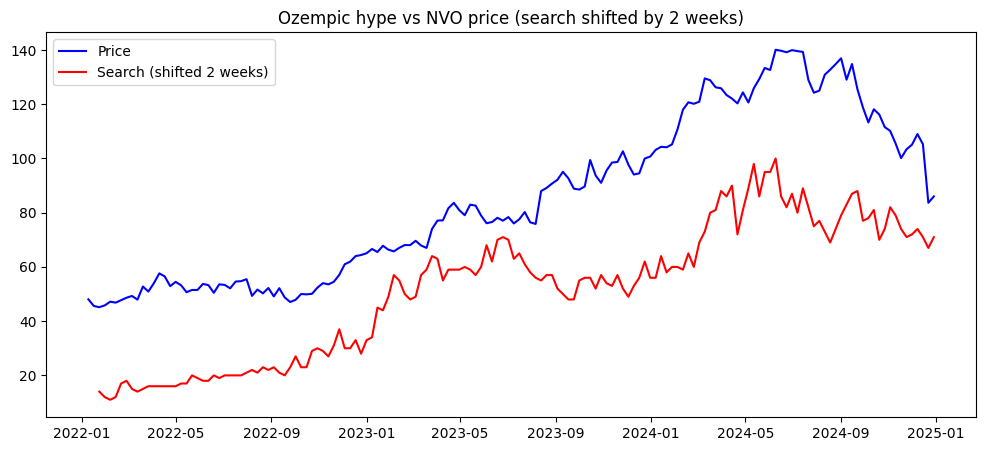

In [30]:
lag = int(best_lag_row['lag'])

df['search_shifted'] = df['search'].shift(lag)

plt.figure(figsize=(12,5))
plt.plot(df.index, df['price'], label='Price', color='blue')
plt.plot(df.index, df['search_shifted'], label=f'Search (shifted {lag} weeks)', color='red')
plt.legend()
plt.title(f'Ozempic hype vs NVO price (search shifted by {lag} weeks)')
plt.show()

In [31]:
df_norm = df.copy()

df_norm['search_z'] = (df_norm['search'] - df_norm['search'].mean()) / df_norm['search'].std()
df_norm['price_z']  = (df_norm['price']  - df_norm['price'].mean())  / df_norm['price'].std()

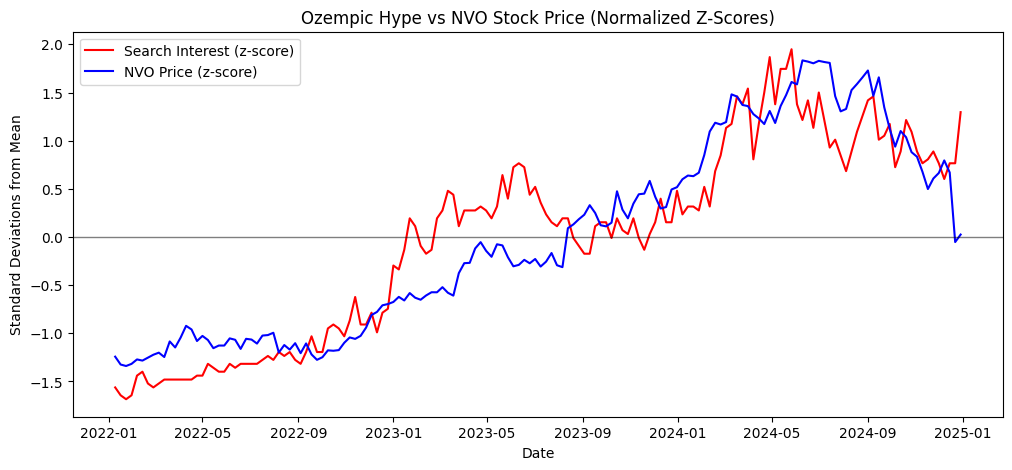

In [32]:
plt.figure(figsize=(12,5))
plt.plot(df_norm.index, df_norm['search_z'], label='Search Interest (z-score)', color='red')
plt.plot(df_norm.index, df_norm['price_z'],  label='NVO Price (z-score)',     color='blue')

plt.axhline(0, color='black', linewidth=1, alpha=0.5)

plt.title('Ozempic Hype vs NVO Stock Price (Normalized Z-Scores)')
plt.xlabel('Date')
plt.ylabel('Standard Deviations from Mean')
plt.legend()
plt.show()

In [33]:
lag = best_lag_row['lag']

df_norm['search_shifted_z'] = df_norm['search_z'].shift(lag)

plt.figure(figsize=(12,5))
plt.plot(df_norm.index, df_norm['price_z'],             label='Price (z)', color='blue')
plt.plot(df_norm.index, df_norm['search_shifted_z'],    label=f'Search shifted {lag} weeks (z)', color='red')

plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.title(f'Ozempic Hype (Shifted) vs NVO Price\nShift = {lag} weeks')
plt.xlabel('Date')
plt.ylabel('Standard Deviations from Mean')
plt.legend()
plt.show()

TypeError: slice indices must be integers or None or have an __index__ method

In [34]:
lag = int(best_lag_row['lag'])  # cast to int

df_norm['search_shifted_z'] = df_norm['search_z'].shift(lag)

In [35]:
lag = int(round(float(best_lag_row['lag'])))
print("Using lag:", lag)

df_norm['search_shifted_z'] = df_norm['search_z'].shift(lag)

Using lag: 2


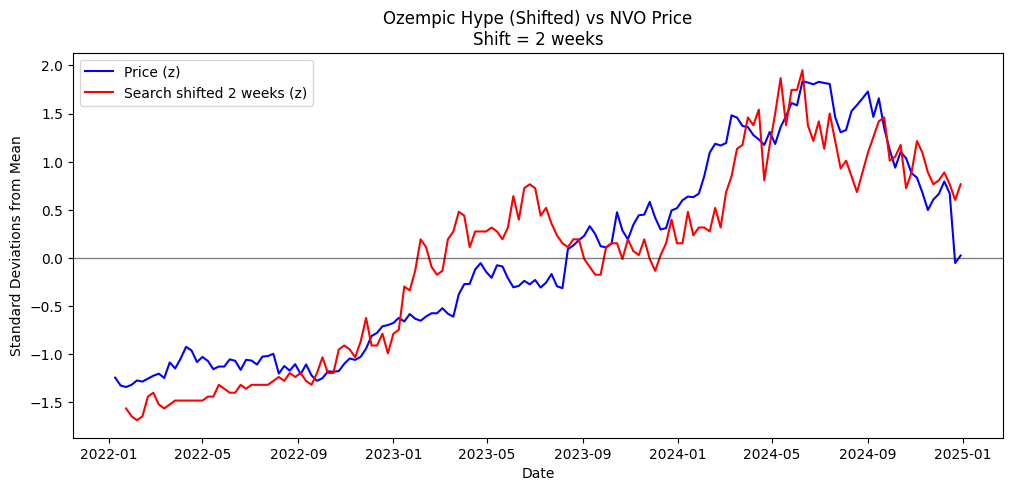

In [36]:
plt.figure(figsize=(12,5))
plt.plot(df_norm.index, df_norm['price_z'],          label='Price (z)', color='blue')
plt.plot(df_norm.index, df_norm['search_shifted_z'], label=f'Search shifted {lag} weeks (z)', color='red')

plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.title(f'Ozempic Hype (Shifted) vs NVO Price\nShift = {lag} weeks')
plt.xlabel('Date')
plt.ylabel('Standard Deviations from Mean')
plt.legend()
plt.show()